# Dimensionality Reduction and Projection

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V06a — "Dimensionality Reduction and Projection" (DeepLearning.AI).*

The course's final topic is **Principal Component Analysis (PCA)** — reducing the number of **columns (features)** of a dataset while keeping as much information as possible. The dataset stays just as **tall** (same rows/observations) but gets **skinnier** (fewer columns). The mechanism is **projection**, which we build up here:

- Why naive **column deletion** loses information.
- **Projecting** points onto a line, worked out with the dot product and normalization.
- The general formula $A_P = A V$ and projecting onto **several** directions at once.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Why reduce dimensions — and why not just delete columns

A dataset has **observations** (rows) and **features** (columns). Two reasons to shrink the number of features:

1. **Size** — real datasets can have hundreds or thousands of features; smaller is easier to work with.
2. **Visualization** — scatter/bar charts show only one or two features at a time, so fewer dimensions makes patterns visible.

The **naive** approach is to just **delete columns** — but that throws away all the information they held. **PCA** reduces dimensions while **preserving** much of that information, by *projecting* rather than deleting.

## 2. Projecting points onto a line

Take four 2D observations $(x, y)$ and project them onto the line $y = x$. Each point moves **perpendicularly** onto the line; a point already on the line (like $(1,1)$) doesn't move.

A point on the line can be described by a **single number**: its signed distance from the origin along the line. For $(1,1)$ that distance is $\sqrt{2}$ — and notice

$$ \sqrt{2} = \frac{1 + 1}{\sqrt{2}}, $$

where the $1 + 1$ is the **dot product** of the point with the direction vector $(1,1)$ (the line $y=x$ is the span of $(1,1)$), and dividing by $\sqrt2 = \|(1,1)\|$ removes the stretch. So the projected coordinate is

$$ \text{proj}(x,y) = \frac{(x,y)\cdot(1,1)}{\|(1,1)\|} = \frac{x + y}{\sqrt2}. $$

*(The 2D points below are reconstructed to match the projected values stated in the lecture.)*

In [2]:
# 4 observations, 2 features (x, y)  -- rows 1-2 from the video; rows 3-4 reconstructed
A = np.array([[ 1.0,  1.0],
              [ 1.2,  1.6],
              [-0.3,  0.0],
              [-0.5, -1.4]])

v = np.array([1, 1])              # direction of the line y = x
v_unit = v / np.linalg.norm(v)    # normalize: divide by ||v|| = sqrt(2)

proj = A @ v_unit                 # projected 1-D coordinate for each point
print('unit direction v/||v|| =', v_unit)
print('projected coordinates  =', proj)   # -> 1.4142, 1.9799, -0.2121, -1.3435

unit direction v/||v|| = [0.7071 0.7071]
projected coordinates  = [ 1.4142  1.9799 -0.2121 -1.3435]


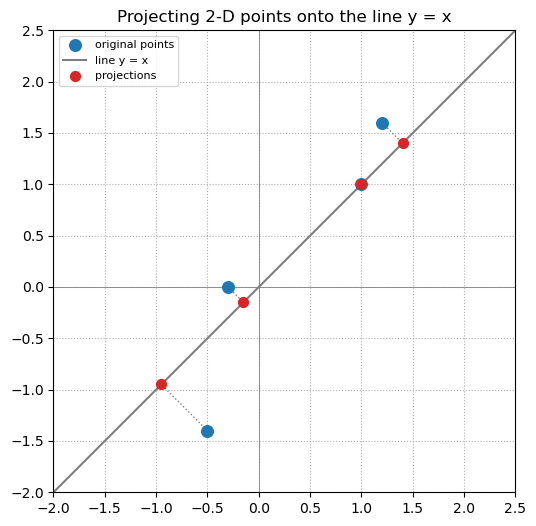

In [3]:
# Visualize the perpendicular projections onto y = x
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(A[:, 0], A[:, 1], color='C0', s=70, zorder=5, label='original points')
# the line y = x
t = np.linspace(-2, 2.5, 2)
ax.plot(t, t, 'C7', lw=1.5, label='line y = x')
# projected points = proj * unit direction, drawn with perpendicular dashes
P = proj[:, None] * v_unit
ax.scatter(P[:, 0], P[:, 1], color='C3', s=50, zorder=5, label='projections')
for a, p in zip(A, P):
    ax.plot([a[0], p[0]], [a[1], p[1]], 'gray', ls=':', lw=1)
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.legend(fontsize=8)
ax.set_xlim(-2, 2.5); ax.set_ylim(-2, 2.5)
ax.set_title('Projecting 2-D points onto the line y = x')
plt.show()

## 3. The general projection formula

To project a data matrix $A$ onto a direction $v$: multiply by $v$, but first **scale $v$ to norm 1** (divide by $\|v\|$) so no stretching is introduced:

$$ A_P = A\,\frac{v}{\|v\|}. $$

**Dimensions matter:** if $A$ is $R \times C$ (R observations, C features), then $v$ has length $C$ (a $C \times 1$ matrix), and the projection $A_P$ is $R \times 1$ — same observations, **one** feature. We went from a 2-column matrix to a single column vector.

In [4]:
print('A shape       :', A.shape, ' (4 obs, 2 features)')
print('v_unit shape  :', v_unit.shape, ' (length C = 2)')
print('projection    :', proj.shape, ' (4 obs, 1 feature)')
print()
print('one column now represents each point along the line:')
print(proj.reshape(-1, 1))

A shape       : (4, 2)  (4 obs, 2 features)
v_unit shape  : (2,)  (length C = 2)
projection    : (4,)  (4 obs, 1 feature)

one column now represents each point along the line:
[[ 1.4142]
 [ 1.9799]
 [-0.2121]
 [-1.3435]]


## 4. Projecting onto several directions at once

Projecting onto **two** vectors is the same as projecting onto the **plane** they span. Stack the (normalized) directions as columns of a matrix $V$ of size $C \times k$; then

$$ \boxed{\,A_P = A\,V\,} $$

gives an $R \times k$ result — same observations, now $k$ features. Reducing from $C$ features to $k < C$ is a single matrix multiply once you have $V$.

In [5]:
# Reduce a 4-feature dataset to 2 features by projecting onto 2 directions
A4 = np.array([[2.0, 0.5, 1.0, 3.0],
               [1.0, 2.0, 0.0, 1.5],
               [0.5, 1.0, 2.0, 0.5],
               [3.0, 1.5, 1.0, 2.0]])   # 4 obs x 4 features

v1 = np.array([1, 1, 0, 0], dtype=float)
v2 = np.array([0, 0, 1, 1], dtype=float)
V = np.column_stack([v1 / np.linalg.norm(v1),
                     v2 / np.linalg.norm(v2)])   # C x 2, normalized columns

A_P = A4 @ V                                       # R x 2
print('A4 shape :', A4.shape, ' -> reduced A_P shape :', A_P.shape)
print('A_P =')
print(A_P)

A4 shape : (4, 4)  -> reduced A_P shape : (4, 2)
A_P =
[[1.7678 2.8284]
 [2.1213 1.0607]
 [1.0607 1.7678]
 [3.182  2.1213]]


## 5. The remaining question

Projection cleanly reduces dimensions — but **which** vectors should you project onto? A bad choice loses information; a good one keeps the data's spread intact. Choosing the **best** directions (the ones capturing the most variance) is exactly what **PCA** does, using the **eigenvectors** of the data's covariance — the topic that comes next.

## Summary

- **Dimensionality reduction** keeps all observations (rows) but reduces features (columns); **deleting columns** loses information, so we **project** instead.
- Projecting onto a direction $v$: $A_P = A\,\dfrac{v}{\|v\|}$ — the dot product places each point along $v$, and dividing by $\|v\|$ removes stretching (a unit direction).
- **Shapes:** $A$ is $R \times C$, $v$ is length $C$, projection is $R \times 1$. Onto $k$ directions stacked as columns of $V$ ($C \times k$): $A_P = A V$ is $R \times k$.
- The open question — *which* directions to project onto — is answered by **PCA** via **eigenvectors** of the covariance matrix.